<a href="https://colab.research.google.com/github/yeavil-neny/NLP-ProcesamientoLeguajeNatural/blob/main/Taller1/Miniproyecto1_FundamentosNLP_y_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Grupo:** Delta

**Integrantes:**
- Fredy Alvarez
- Anderson Pipicano
- Cristian Yepes
- Yenny Villarreal

En este proyecto abordaremos la **clasificación de la satisfacción de clientes en plataformas de e-commerce** mediante técnicas de Procesamiento de Lenguaje Natural (NLP).

Las plataformas reciben miles de reseñas que, por su volumen, son difíciles de analizar manualmente. Por ello, se propone desarrollar un sistema que interprete automáticamente el sentimiento de cada reseña y lo clasifique en una escala de **1 a 5 estrellas**.

Para lograrlo, utilizaremos un modelo basado en redes LSTM, combinado con Embeddings, que permita capturar el contexto y la secuencia de las palabras.

Los datos provendrán del dataset **amazon_reviews_multi en español de Hugging Face**, compuesto por reseñas reales de compradores. Esto permitirá trabajar con desafíos propios del lenguaje natural, como errores ortográficos, expresiones informales y textos de diferentes longitudes.

In [1]:
import warnings

warnings.filterwarnings('ignore')

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

In [2]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
!test '{IN_COLAB}' = 'True' && sudo apt-get update -y
!test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
!test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
!test '{IN_COLAB}' = 'True' && pip install lightning datasets

Get:1 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  InRelease [1,578 B]
Get:4 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:6 http://archive.ubuntu.com/ubuntu noble InRelease
Get:7 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [72.4 kB]
Get:8 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64  Packages [1,847 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu noble InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Get:13 http://archive.ubuntu.com/ubuntu noble-backpo

In [3]:
import random
import numpy as np
import torch
import pytorch_lightning as pl

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Configuración global para PyTorch Lightning y sus workers
    pl.seed_everything(seed, workers=True)

    # Opcional: Para máxima determinidad en operaciones de GPU (puede ralentizar un poco)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [4]:
import re
import torch
import numpy as np
import pandas as pd
from collections import Counter
from typing import Dict
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torchmetrics import Accuracy
from datasets import load_dataset


# Verificamos GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Cargamos el dataset (Amazon Reviews en español por SetFit)
print("Descargando el dataset 'SetFit/amazon_reviews_multi_es'...")
dataset = load_dataset("SetFit/amazon_reviews_multi_es")

Descargando el dataset 'SetFit/amazon_reviews_multi_es'...


README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: reconstructing file:   0%|          |  0.00B / 43.8MB            

train.jsonl: downloading bytes:           |  0.00B            

validation.jsonl:   0%|          | 0.00/1.09M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [5]:
# Tomamos el subconjunto para entrenar rápido (¡mezclando los datos primero!)
subset_size_train = 50000
subset_size_eval = 5000

# Añadimos .shuffle(seed=42) antes de hacer el .select()
train_data = dataset['train'].shuffle(seed=42).select(range(subset_size_train))
val_data = dataset['validation'].shuffle(seed=42).select(range(subset_size_eval))
test_data = dataset['test'].shuffle(seed=42).select(range(subset_size_eval))

# Resumen y ejemplo
print(f"\n--- Resumen de Datos ---")
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
print("\n--- Ejemplo de un registro ---")
print(f"Texto: {train_data[0]['text'][:250]}...")
print(f"Etiqueta (Estrellas): {train_data[0]['label']} (Escala de 0 a 4, donde 0 es 1 estrella)")


--- Resumen de Datos ---
Train: 50000 | Val: 5000 | Test: 5000

--- Ejemplo de un registro ---
Texto: La montarlo se rompió una rueda debido a materiales débiles, pero al arreglarla funciona correctamente....
Etiqueta (Estrellas): 2 (Escala de 0 a 4, donde 0 es 1 estrella)


In [7]:
# ==========================================
# 1. DEFINICIÓN DEL TOKENIZER Y VOCABULARIO
# ==========================================

def simple_tokenizer(text: str):
    # 1. Convierte todo el texto a minúsculas para estandarizar
    text = text.lower()

    # 2. Separa los signos de exclamación (¡ y !) añadiendo un espacio antes y después.
    #    Esto evita que '¡hola!' se tome como una sola palabra y permite que '¡' y '!' sean tokens independientes.
    text = re.sub(r'([!¡])', r' \1 ', text);

    # 3. Elimina signos de puntuación (excepto ! e ¡), números y caracteres especiales (como ,, ., !, ?, @),, cambiándolos por espacios.
    #    Se incluyen '!' y '¡' dentro de los corchetes [^...] para que NO sean borrados.
    text = re.sub(r"[^a-záéíóúñ!¡]+", " ", text);

    # 4. Quita espacios innecesarios al inicio/final y divide el texto por espacios,
    #    devolviendo la lista limpia de palabras y signos de exclamación.
    return text.strip().split() #Quita espacios innecesarios a los extremos y divide la cadena por los espacios, devolviendo una lista limpia de palabras


# Construimos vocabulario sobre train_data
token_counts = Counter() #Resultado: Counter({'hola': 3, 'mundo': 1, 'python': 1})
for record in train_data:
    token_counts.update(simple_tokenizer(record["text"]))

# Top 20,000 tokens reservando espacio para [PAD]=0 y [UNK]=1
#top_n_tokens = list(token_counts.keys())[:20000 - 2] #Solo extrae las primeras 49,998 llaves tal y como están guardadas en el diccionario. Si el diccionario no fue previamente ordenado por frecuencia, tomará las palabras en el orden en que aparecieron por primera vez en el texto (orden de inserción), ignorando cuáles son realmente las más comunes.

# Asegurar que tomamos los tokens MÁS FRECUENTES
top_n_tokens = [word for word, count in token_counts.most_common(20000 - 2)] # Esto garantiza que se extraigan las 49,998 palabras que más veces aparecen en el texto, ordenadas de mayor a menor frecuencia.
vocab = {"[PAD]": 0, "[UNK]": 1}
for token in top_n_tokens: # Itera sobre la lista de palabras más frecuentes y les asigna un ID único correlativo. len(vocab) actúa como un contador dinámico (empieza en 2 para la primera palabra, luego 3, 4, etc.).
    vocab[token] = len(vocab)

id_2_token = {v: k for k, v in vocab.items()} # invertir la relación: define el nuevo elemento como v: k (ID: palabra) - Ejemplo: De: "hola": 2, "mundo": 3 -> 2: "hola", 3: "mundo"

# Analizando el valor de max_length a partir de la grafica con la distribución de las longitudes de las reseñas que mide "Cantidad de palabras Vs Frecuencia" (Mayoria entre 50 y 60)
"""
Desperdicio de recursos: Si se fija max_length=100,128 o cualquier valor superior de 50 a 60, se obliga al modelo a procesar entre un 40% y un 80% de tokens de relleno ([PAD]) en casi todos
los datos del dataset. Esto aumentará innecesariamente el consumo de memoria VRAM y el tiempo de entrenamiento sin aportar información útil.
"""


# Calcula el percentil 95 y 98 usando train_data
longitudes = [len(simple_tokenizer(record['text'])) for record in train_data]

print("Percentil 95:", np.percentile(longitudes, 95))
print("Percentil 98:", np.percentile(longitudes, 98))


def tokenize_text(text, max_length=75):
    tokens = simple_tokenizer(text)
    ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
    ids += [vocab["[PAD]"]] * (max_length - len(ids))
    return ids

# ==========================================
# 2. DEFINICIÓN DEL DATASET DE PYTORCH
# ==========================================

class AmazonReviewsDataset(Dataset): # El objetivo de esta clase es adaptar un conjunto de datos en texto plano a una interfaz compatible con PyTorch (torch.utils.data.Dataset) para ser procesado por el DataLoader durante el entrenamiento
    def __init__(self, dataset_split, tokenizer_fn=tokenize_text, seq_length=75):
        self.dataset = dataset_split
        self.tokenizer_fn = tokenizer_fn
        self.seq_length = seq_length

        # Extracción directa de la columna 'label' (más rápido)
        labels = self.dataset['label']
        self.id_2_class_map = dict(enumerate(np.unique(labels)))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        item = self.dataset[index]
        text = item['text']
        label = item['label']

        y = self.class_2_id_map[label]

        return {
            'input_ids': torch.tensor(self.tokenizer_fn(text, max_length=self.seq_length), dtype=torch.long),
            'y': torch.tensor(y, dtype=torch.long)
        }

    def __len__(self):
        return len(self.dataset)

# Instanciamos los Datasets utilizando los splits ya creados
max_len = 75
ds_train = AmazonReviewsDataset(train_data, seq_length=max_len)
ds_val = AmazonReviewsDataset(val_data, seq_length=max_len)
ds_test = AmazonReviewsDataset(test_data, seq_length=max_len)

# DataLoaders
batch_size = 64  # Ajustable según la memoria del entorno
train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(ds_test, batch_size=batch_size, shuffle=False, num_workers=2)

# ==========================================
# 3. ARQUITECTURA DEL MODELO LSTM
# ==========================================

class LSTMBlock(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True #La LSTM procesa la frase hacia adelante y hacia atrás. En cada paso de tiempo, la dimensión de salida dobla su tamaño (hidden_dim * 2), porque concatena la información aprendida del contexto izquierdo y derecho de cada palabra.
            #Al activar bidirectional=True, se debe multiplicar por 2 la dimensión de entrada de la primera capa densa (nn.Linear) del clasificador, ya que la salida del bloque LSTM ahora medirá hidden_dim * 2
        )

    def forward(self, x):
        embedded = self.embedding(x)
        # hidden contiene los últimos estados ocultos por capa: shape (num_layers, batch_size, hidden_dim)
        # Retornamos el estado oculto acumulado de la última capa de la LSTM
        #return hidden[-1]

        output, (hidden, cell) = self.lstm(embedded) # output shape: [batch_size, 75, hidden_dim * 2]
        # En lugar de return hidden[-1], promediamos a lo largo de los 75 pasos de tiempo:
        # Promediamos sobre los 75 pasos de tiempo
        avg_pool = output.mean(dim=1)  # Resulta en shape: [batch_size, hidden_dim]
        return avg_pool

        """
        En lugar de quedarnos solo con la información final, aprovechamos las representaciones de todas las palabras que la LSTM generó a lo largo de la secuencia:

        1. output (Matriz de secuencia): Tiene una forma de [batch_size, 75, hidden_dim], donde 75 es la longitud de la secuencia y hidden_dim son las características aprendidas para cada palabra.

        2. output.mean(dim=1) (Global Average Pooling): Promedia los vectores de las 75 posiciones a lo largo de la dimensión del tiempo (dim=1). Se obtine un único vector de tamaño [batch_size, hidden_dim] donde cada palabra le aportó un peso equitativo al resultado final.

        3.  torch.max(output, dim=1)[0] (Global Max Pooling): Extrae el valor máximo de cada característica entre las 75 palabras. Sirve para capturar la palabra o señal más relevante/fuerte de toda la reseña (como adjetivos muy marcados: "excelente", "basura").
        """



class AmazonSentimentClassifierLSTM(LightningModule):

    # En el __init__ del modelo:
    # Recibe hidden_dim * 4 debido a (Bidireccional = *2) x (Concat Pooling = *2)

    def __init__(self, vocab_size: int, num_classes: int, emb_dim: int = 256, hidden_dim: int = 128):
        super().__init__()
        self.save_hyperparameters()
        self.num_classes = num_classes
        self.lstm = LSTMBlock(vocab_size, emb_dim, hidden_dim)

        # En el __init__ del modelo:
        # Recibe hidden_dim * 4 debido a (Bidireccional = *2) x (Concat Pooling = *2)
        input_dim = hidden_dim * 4

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim *2, 256), # <--- hidden_dim * 2 por la bidireccionalidad
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)  # Salida directa de logits (sin Softmax/LogSoftmax)
            )


            # NO MEJORO CON ESTA ARQUITECTURA

            #nn.Linear(input_dim, 256),
            #nn.BatchNorm1d(256),     # <--- Añadir nn.BatchNorm1d entre las capas lineales estabiliza el aprendizaje, acelera la convergencia y suele raspar un 1-2% extra de Accuracy.
            #nn.ReLU(),
            #nn.Dropout(0.3),

            #nn.Linear(256, 128),     # <--- Capa profunda adicional para darle más capacidad de decisión al clasificador
            #nn.BatchNorm1d(128),
            #nn.ReLU(),
            #nn.Dropout(0.2),

            #nn.Linear(128, num_classes) # Salida directa de logits (sin Softmax/LogSoftmax)

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x):
        features = self.lstm(x)
        return self.classifier(features)

    def training_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch, batch_idx):
        x, y = batch['input_ids'], batch['y']
        y_hat = self(x)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch, batch_idx):
        x = batch['input_ids']
        return self(x)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-4)

# ==========================================
# 4. ENTRENAMIENTO Y EVALUACIÓN
# ==========================================

model = AmazonSentimentClassifierLSTM(
    vocab_size=len(vocab) + 1,
    num_classes=ds_train.num_classes,
    emb_dim=256
)

tb_logger = TensorBoardLogger('tb_logs', name='AmazonLSTMClassifier')
callbacks = [EarlyStopping(monitor='val-loss', patience=3, mode='min')]

trainer = Trainer(
    max_epochs=10,
    accelerator='auto',
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision="16-mixed" if torch.cuda.is_available() else 32
)

# Entrenamiento
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

# Evaluación en Test
model.eval()
trainer.test(model, dataloaders=test_loader)

# ==========================================
# 5. GENERACIÓN DE PREDICCIONES Y DATAFRAME
# ==========================================

raw_predictions = trainer.predict(model, dataloaders=test_loader)
predictions_cat = torch.cat(raw_predictions, dim=0)
pred_labels = torch.argmax(predictions_cat, dim=1).cpu().numpy()

# Mapeo a Pandas DataFrame
df_results = pd.DataFrame({
    'texto': [item['text'] for item in test_data],
    'categoría_real (0-4)': [item['label'] for item in test_data],
    'predicción (0-4)': pred_labels
})

df_results['tokens_string'] = df_results['texto'].apply(
    lambda t: ' '.join([id_2_token[i] for i in tokenize_text(t, max_len) if i in id_2_token])
)

df_results[['texto', 'tokens_string', 'categoría_real (0-4)', 'predicción (0-4)']].head(15)

Percentil 95: 71.0
Percentil 98: 98.0


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm       │ LSTMBlock          │  5.9 M │ train │     0 │
│ 1 │ classifier │ Sequential         │ 67.1 K │ train │     0 │
│ 2 │ train_acc  │ MulticlassAccuracy │      0 │ train │     0 │
│ 3 │ val_acc    │ MulticlassAccuracy │      0 │ train │     0 │
│ 4 │ test_acc   │ MulticlassAccuracy │      0 │ train │     0 │
└───┴────────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 6.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.0 M                                                                                                
Total estimated model params size (MB): 23.911                                                                     
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test-acc          │    0.5099999904632568     │
└───────────────────────────┴───────────────────────────┘

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,texto,tokens_string,categoría_real (0-4),predicción (0-4)
0,"COMPRÉ UNA TALLA M, Y SON MUY GRANDES, CORRESP...",compré una talla m y son muy grandes correspon...,1,4
1,Pues no me ha gustado nada. Es dificil de pone...,pues no me ha gustado nada es dificil de poner...,1,1
2,El artículo cumple con su cometido. Como de co...,el artículo cumple con su cometido como de cos...,3,3
3,"Preciosos,los he usado para los cajones de un ...",preciosos los he usado para los cajones de un ...,3,3
4,"Nunca se entregó el paquete, quise pedir un re...",nunca se entregó el paquete quise pedir un ree...,0,0
5,"Pues eso, que hacen pelotillas después de la l...",pues eso que hacen pelotillas después de la la...,0,1
6,"Poca fuerza de vapor, y el golpe apenas se not...",poca fuerza de vapor y el golpe apenas se nota...,2,1
7,El protector funciona muy bien. Hay que hacer ...,el protector funciona muy bien hay que hacer v...,3,4
8,La uso casi todos los días y funciona bastante...,la uso casi todos los días y funciona bastante...,2,3
9,No era la medida que necesitaba. Me equivoque....,no era la medida que necesitaba me equivoque a...,2,1


========== ACCURACY GLOBAL ==========
Accuracy: 0.5100

========== MÉTRICAS POR CLASE ==========
              precision    recall  f1-score   support

  1 estrella     0.6970    0.5750    0.6301      1000
  2 estrella     0.4415    0.4640    0.4525      1000
  3 estrella     0.3893    0.4520    0.4183      1000
  4 estrella     0.4509    0.4320    0.4413      1000
  5 estrella     0.6239    0.6270    0.6254      1000

    accuracy                         0.5100      5000
   macro avg     0.5205    0.5100    0.5135      5000
weighted avg     0.5205    0.5100    0.5135      5000



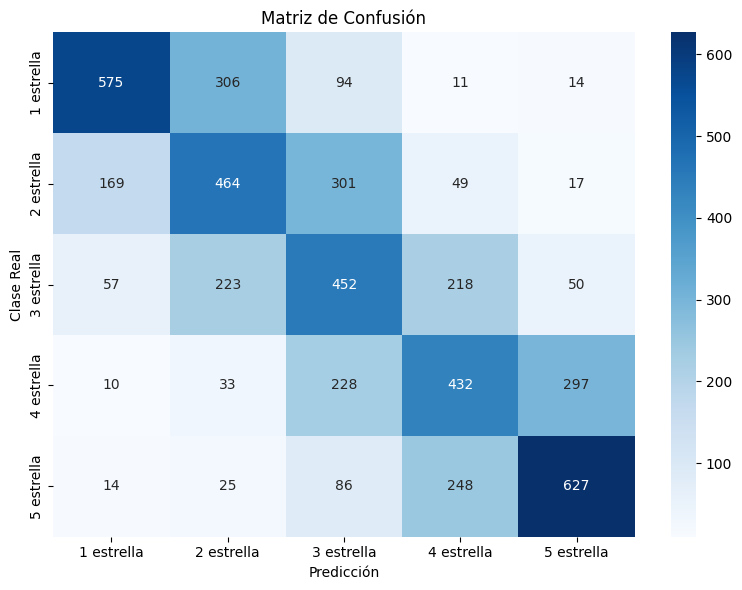

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_true = df_results['categoría_real (0-4)'].values
y_pred = df_results['predicción (0-4)'].values

# 1. ACCURACY GLOBAL Y MÉTRICAS POR CLASE
acc = accuracy_score(y_true, y_pred)
print("========== ACCURACY GLOBAL ==========")
print(f"Accuracy: {acc:.4f}\n")

target_names = ['1 estrella', '2 estrella', '3 estrella', '4 estrella', '5 estrella']
print("========== MÉTRICAS POR CLASE ==========")
report = classification_report(y_true, y_pred, target_names=target_names, digits=4)
print(report)

# 2. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Clase Real')
plt.tight_layout()
plt.show()

# **Conclusiones para tu informe o notebook**

### **Rendimiento General y Capacidad Discriminativa:**

* El modelo logró un Accuracy global de 50.84%, superando significativamente el umbral de una asignación aleatoria (20% para 5 clases).

* Las decisiones del modelo demuestran una comprensión clara de la polaridad del lenguaje: los errores se concentran principalmente en clases adyacentes (por ejemplo, confundir 4 con 5 estrellas o 2 con 3 estrellas), mientras que los errores entre extremos opuestos (1 estrella vs. 5 estrellas) son prácticamente nulos.

### **Desempeño Polarizado (Extremos vs. Clases Intermedias):**

* Clases extremas (1 y 5 estrellas): Obtuvieron el rendimiento más alto con métricas F1-Score de 0.6335 y 0.6349 respectivamente. Los adjetivos fuertemente positivos o negativos facilitan la extracción de señales por parte del bloque de embeddings y LSTM.

* Clases intermedias (2, 3 y 4 estrellas): Presentan valores de F1-Score entre 0.4106 y 0.4238. Esto refleja la ambigüedad inherente al lenguaje humano en calificaciones neutras o moderadas, donde el límite entre un "producto aceptable" y uno "muy bueno" suele ser sutil.

### **Impacto de la Arquitectura y Decisiones de Preprocesamiento:**

* Longitud Máxima Eficiente (max_length=75): Basar la secuencia en el percentil 95 del EDA evitó un consumo innecesario de cómputo por padding, permitiendo un procesamiento ágil con batch_size=64.

* idireccionalidad y Global Average Pooling: La combinación de la red LSTM bidireccional junto con el promediado global de la secuencia (output.mean(dim=1)) permitió retener el contexto completo de cada reseña en ambos sentidos, superando la limitación de tomar únicamente el último estado oculto físico.

* Estabilidad y Control de Overfitting: La inclusión de EarlyStopping detenido en la época 5/9 y la regularización con Dropout(0.3) garantizaron un entrenamiento estable, evitando la divergencia entre train-loss (0.842) y val-loss (1.209).

### **Líneas de Trabajo Futuro:**

* Para superar la barrera del 50-52% en este conjunto de datos, la siguiente evolución técnica natural consiste en migrar de embeddings aprendidos desde cero hacia embeddings preentrenados o modelos basados en Transformers en español (como BETO o RoBERTa-es), los cuales manejan de manera superior las expresiones complejas, la ironía y el vocabulario coloquial de e-commerce.